# Detecção de Discurso de Ódio em Português Brasileiro
## Notebook único e unificado para Google Colab

Este arquivo reúne todo o projeto: download e auditoria do HateBR, exploração, divisão reproduzível, seis encoders, instruções em inglês/português, geração automática opcional, cache seguro, classificação, métricas, gráficos e análise de erros.

> **Aviso ético:** o corpus contém linguagem ofensiva e tem licença de pesquisa CC BY-NC 4.0.

## Decisões após analisar todos os arquivos
- O PDF é um rascunho de 8 páginas com Introdução, Trabalhos Relacionados e Metodologia, ainda sem Resultados/Conclusão.
- O notebook antigo possui 49 células e parou ao não encontrar o CSV.
- Os nove caches antigos têm vetores válidos, mas não identificam o encoder/revisão.
- 279 instruções automáticas do teste legado estão ausentes; nada disso será reutilizado como resultado final.
- E5-base suporta português, mas usa apenas `query:`; instrução livre pertence ao E5-large-instruct.
- Modelos não instrucionais executam somente o baseline.

## Sumário
1. Instalação
2. Modelos
3. Dados e pré-processamento
4. Análise exploratória
5. Divisão 70/15/15
6. Instruções
7. Embeddings e cache
8. Classificação
9. Execução
10. Resultados e erros
11. LLM opcional
12. Exportação

## 1. Instalação e ambiente

In [ ]:
%pip install -q "sentence-transformers>=3,<6" "scikit-learn>=1.5,<2" "requests>=2.32,<3" "seaborn>=0.13,<1" "tqdm>=4.66,<5"

In [ ]:
import gc, hashlib, json, os, platform, re, shutil, sys, time, urllib.request
from collections.abc import Iterable, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
pd.set_option("display.max_colwidth",120); sns.set_theme(style="whitegrid")
try:
 import torch
 DEVICE_INFO=torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
except ImportError: DEVICE_INFO="CPU"
print("Python:",sys.version.split()[0],"| Dispositivo:",DEVICE_INFO)

Python: 3.12.13 | Dispositivo: Tesla T4


## 2. Configuração e modelos
O registro distingue suporte ao português de suporte a instruções livres.

In [ ]:
# 1. CONFIGURAÇÃO
# =============================================================================

SEED = 42
TEXT_COL = "comentario"
LABEL_COL = "label_final"
ID_COL = "id"

SEM_INSTRUCAO = "sem_instrucao"
MANUAL_EN = "manual_en"
MANUAL_PT = "manual_pt"
AUTOMATICA_EN = "automatica_en"
AUTOMATICA_PT = "automatica_pt"

TODAS_CONDICOES = (
    SEM_INSTRUCAO,
    MANUAL_EN,
    MANUAL_PT,
    AUTOMATICA_EN,
    AUTOMATICA_PT,
)
CONDICOES_INSTRUCIONAIS = frozenset(
    {MANUAL_EN, MANUAL_PT, AUTOMATICA_EN, AUTOMATICA_PT}
)

REQUIRED_COLUMNS = {
    ID_COL,
    TEXT_COL,
    "anotator1",
    "anotator2",
    "anotator3",
    LABEL_COL,
    "links_post",
    "account_post",
}

MANUAL_INSTRUCTIONS = {
    "en": (
        "Represent the Brazilian Portuguese comment for hate speech detection. "
        "Consider insults, discrimination, prejudice, attacks on protected groups, "
        "irony, implicit hostility, and offensive language."
    ),
    "pt": (
        "Represente o comentário em português brasileiro para detecção de discurso "
        "de ódio. Considere insultos, discriminação, preconceito, ataques a grupos "
        "protegidos, ironia, hostilidade implícita e linguagem ofensiva."
    ),
}


@dataclass(frozen=True, slots=True)
class ModelConfig:
    """Protocolo e metadados de um encoder."""

    name: str
    hf_id: str
    input_style: str
    supports_instructions: bool
    language_scope: str
    dimensions: int
    max_tokens: int
    role: str
    source_url: str

    def supports_condition(self, condition: str) -> bool:
        if condition == SEM_INSTRUCAO:
            return True
        return self.supports_instructions and condition in CONDICOES_INSTRUCIONAIS


MODEL_REGISTRY: dict[str, ModelConfig] = {
    "e5_base": ModelConfig(
        name="e5_base",
        hf_id="intfloat/multilingual-e5-base",
        input_style="e5_query",
        supports_instructions=False,
        language_scope="Multilíngue (100 idiomas; inclui português via XLM-R)",
        dimensions=768,
        max_tokens=512,
        role="Controle E5 multilíngue sem instrução livre",
        source_url="https://huggingface.co/intfloat/multilingual-e5-base",
    ),
    "e5_large_instruct": ModelConfig(
        name="e5_large_instruct",
        hf_id="intfloat/multilingual-e5-large-instruct",
        input_style="e5_instruct",
        supports_instructions=True,
        language_scope="Multilíngue (100 idiomas; inclui português via XLM-R)",
        dimensions=1024,
        max_tokens=512,
        role="Modelo instrucional principal",
        source_url="https://huggingface.co/intfloat/multilingual-e5-large-instruct",
    ),
    "minilm_multilingual": ModelConfig(
        name="minilm_multilingual",
        hf_id="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        input_style="plain",
        supports_instructions=False,
        language_scope="Multilíngue (50 idiomas)",
        dimensions=384,
        max_tokens=128,
        role="Controle multilíngue leve para execução rápida",
        source_url=(
            "https://huggingface.co/sentence-transformers/"
            "paraphrase-multilingual-MiniLM-L12-v2"
        ),
    ),
    "mpnet_multilingual": ModelConfig(
        name="mpnet_multilingual",
        hf_id="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
        input_style="plain",
        supports_instructions=False,
        language_scope="Multilíngue (50 idiomas)",
        dimensions=768,
        max_tokens=128,
        role="Controle multilíngue independente da família E5",
        source_url=(
            "https://huggingface.co/sentence-transformers/"
            "paraphrase-multilingual-mpnet-base-v2"
        ),
    ),
    "bertimbau_sts": ModelConfig(
        name="bertimbau_sts",
        hf_id="rufimelo/bert-large-portuguese-cased-sts",
        input_style="plain",
        supports_instructions=False,
        language_scope="Português brasileiro",
        dimensions=1024,
        max_tokens=128,
        role="Controle monolíngue ajustado para similaridade textual",
        source_url="https://huggingface.co/rufimelo/bert-large-portuguese-cased-sts",
    ),
    "bge_m3": ModelConfig(
        name="bge_m3",
        hf_id="BAAI/bge-m3",
        input_style="plain",
        supports_instructions=False,
        language_scope="Multilíngue (mais de 100 idiomas)",
        dimensions=1024,
        max_tokens=8192,
        role="Controle multilíngue moderno e independente",
        source_url="https://huggingface.co/BAAI/bge-m3",
    ),
}

DEFAULT_MODELS = ("e5_base", "e5_large_instruct", "minilm_multilingual")
DEFAULT_CONDITIONS = (SEM_INSTRUCAO, MANUAL_EN, MANUAL_PT)



In [ ]:
display(pd.DataFrame([{"nome":c.name,"huggingface_id":c.hf_id,"idiomas":c.language_scope,"aceita_instrucoes":c.supports_instructions,"dimensoes":c.dimensions,"papel":c.role} for c in MODEL_REGISTRY.values()]))

,nome,huggingface_id,idiomas,aceita_instrucoes,dimensoes,papel
0,e5_base,intfloat/multilingual-e5-base,Multilíngue (100 idiomas; inclui português via XLM-R),False,768,Controle E5 multilíngue sem instrução livre
1,e5_large_instruct,intfloat/multilingual-e5-large-instruct,Multilíngue (100 idiomas; inclui português via XLM-R),True,1024,Modelo instrucional principal
2,minilm_multilingual,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,Multilíngue (50 idiomas),False,384,Controle multilíngue leve para execução rápida
3,mpnet_multilingual,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,Multilíngue (50 idiomas),False,768,Controle multilíngue independente da família E5
4,bertimbau_sts,rufimelo/bert-large-portuguese-cased-sts,Português brasileiro,False,1024,Controle monolíngue ajustado para similaridade textual
5,bge_m3,BAAI/bge-m3,Multilíngue (mais de 100 idiomas),False,1024,Controle multilíngue moderno e independente


### Fontes dos modelos
- [E5-base multilíngue](https://huggingface.co/intfloat/multilingual-e5-base)
- [E5-large-instruct](https://huggingface.co/intfloat/multilingual-e5-large-instruct)
- [MiniLM multilíngue](https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2)
- [MPNet multilíngue](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2)
- [BERTimbau STS](https://huggingface.co/rufimelo/bert-large-portuguese-cased-sts)
- [BGE-M3](https://huggingface.co/BAAI/bge-m3)

## 3. Carregamento e pré-processamento dos dados

In [ ]:
BASE_DIR=Path("/content") if Path("/content").exists() else Path.cwd()
DATA_PATH=BASE_DIR/"HateBR.csv"; CACHE_DIR=BASE_DIR/"cache_hatebr_v2"; OUTPUT_DIR=BASE_DIR/"resultados_hatebr"
HATEBR_URL="https://raw.githubusercontent.com/franciellevargas/HateBR/main/dataset/HateBR.csv"
if not DATA_PATH.exists():
 try:
  print("Baixando HateBR da fonte oficial..."); urllib.request.urlretrieve(HATEBR_URL,DATA_PATH)
 except Exception as erro_download:
  print("Download falhou:",erro_download)
  from google.colab import files
  uploaded=files.upload()
  if "HateBR.csv" not in uploaded: raise FileNotFoundError("Envie HateBR.csv")
print("Dados:",DATA_PATH); print("Cache:",CACHE_DIR); print("Resultados:",OUTPUT_DIR)

Baixando HateBR da fonte oficial...
Dados: /content/HateBR.csv
Cache: /content/cache_hatebr_v2
Resultados: /content/resultados_hatebr


In [ ]:
# 2. DADOS E DIVISÃO REPRODUZÍVEL
# =============================================================================


@dataclass(slots=True)
class Dataset:
    frame: pd.DataFrame
    sha256: str
    path: Path
    audit: dict[str, Any]


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def load_dataset(path: str | Path) -> Dataset:
    """Carrega o HateBR e interrompe em caso de dados incompatíveis."""

    path = Path(path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Base não encontrada: {path}")

    frame = pd.read_csv(path)
    missing_columns = REQUIRED_COLUMNS - set(frame.columns)
    if missing_columns:
        raise ValueError(
            "Colunas obrigatórias ausentes: " + ", ".join(sorted(missing_columns))
        )

    null_required = frame[[ID_COL, TEXT_COL, LABEL_COL]].isna().any(axis=1)
    blank_text = frame[TEXT_COL].fillna("").astype(str).str.strip().eq("")
    invalid = null_required | blank_text
    cleaned = frame.loc[~invalid].copy().reset_index(drop=True)

    if cleaned.empty:
        raise ValueError("A base ficou vazia depois da validação.")
    if cleaned[ID_COL].duplicated().any():
        raise ValueError("A coluna 'id' precisa ser única.")

    labels = set(cleaned[LABEL_COL].unique().tolist())
    if labels != {0, 1}:
        raise ValueError(f"Esperava rótulos binários 0/1, mas encontrei: {labels}")

    annotator_cols = ["anotator1", "anotator2", "anotator3"]
    unanimous = cleaned[annotator_cols].nunique(axis=1).eq(1)
    majority = cleaned[annotator_cols].sum(axis=1).ge(2).astype(int)

    audit: dict[str, Any] = {
        "rows_original": len(frame),
        "rows_valid": len(cleaned),
        "rows_removed": int(invalid.sum()),
        "class_counts": {
            str(key): int(value)
            for key, value in cleaned[LABEL_COL].value_counts().sort_index().items()
        },
        "duplicate_comments": int(cleaned[TEXT_COL].duplicated(keep=False).sum()),
        "unanimous_annotations": int(unanimous.sum()),
        "non_unanimous_annotations": int((~unanimous).sum()),
        "final_label_equals_majority": int((majority == cleaned[LABEL_COL]).sum()),
        "unique_posts": int(cleaned["links_post"].nunique()),
        "unique_accounts": int(cleaned["account_post"].nunique()),
    }
    return Dataset(
        frame=cleaned,
        sha256=file_sha256(path),
        path=path,
        audit=audit,
    )


def create_or_load_splits(
    dataset: Dataset,
    output_dir: str | Path,
    seed: int = SEED,
) -> dict[str, pd.DataFrame]:
    """Cria 70/15/15 estratificado e persiste os mesmos IDs para todos os modelos."""

    try:
        from sklearn.model_selection import train_test_split
    except ImportError as exc:
        raise RuntimeError(
            "scikit-learn não instalado. Execute: pip install -r requirements.txt"
        ) from exc

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = output_dir / "split_manifest.csv"
    metadata_path = output_dir / "split_manifest.json"

    if manifest_path.exists() and metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        if metadata.get("dataset_sha256") == dataset.sha256 and metadata.get("seed") == seed:
            manifest = pd.read_csv(manifest_path)
            expected_ids = set(dataset.frame[ID_COL].tolist())
            if set(manifest[ID_COL].tolist()) == expected_ids:
                indexed = dataset.frame.set_index(ID_COL, drop=False)
                return {
                    split: indexed.loc[
                        manifest.loc[manifest["split"] == split, ID_COL].tolist()
                    ].reset_index(drop=True)
                    for split in ("train", "valid", "test")
                }

    train, temporary = train_test_split(
        dataset.frame,
        test_size=0.30,
        stratify=dataset.frame[LABEL_COL],
        random_state=seed,
    )
    valid, test = train_test_split(
        temporary,
        test_size=0.50,
        stratify=temporary[LABEL_COL],
        random_state=seed,
    )
    splits = {
        "train": train.reset_index(drop=True),
        "valid": valid.reset_index(drop=True),
        "test": test.reset_index(drop=True),
    }

    manifest = pd.concat(
        [part[[ID_COL]].assign(split=split) for split, part in splits.items()],
        ignore_index=True,
    )
    manifest.to_csv(manifest_path, index=False)
    metadata_path.write_text(
        json.dumps(
            {
                "dataset_sha256": dataset.sha256,
                "seed": seed,
                "sizes": {key: len(value) for key, value in splits.items()},
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
    return splits



In [ ]:
dataset=load_dataset(DATA_PATH); df=dataset.frame
print("Shape:",df.shape,"| SHA-256:",dataset.sha256)
display(pd.DataFrame([dataset.audit]).T.rename(columns={0:"valor"})); display(df.head(15))

Shape: (7000, 8) | SHA-256: 0586a15eea2d9e7743b19ccd5385eedf4074ccf4cfc530cc161bbd3fe5b1ec15


,valor
rows_original,7000
rows_valid,7000
rows_removed,0
class_counts,"{'0': 3500, '1': 3500}"
duplicate_comments,0
unanimous_annotations,5684
non_unanimous_annotations,1316
final_label_equals_majority,7000
unique_posts,78
unique_accounts,6


,id,comentario,anotator1,anotator2,anotator3,label_final,links_post,account_post
0,1,Mais um lixo,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
1,2,Essa nao tem vergonha na cara!!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
2,3,Essa mulher é doente.pilantra!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
3,4,Comunista safada...,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
4,5,Vagabunda. Comunista. Mentirosa. O povo chileno nao merece uma desgraça desta.,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
5,6,"COMUNISTA SAFADA, MALPARIDA, MAMAGUEVA, DESGRAÇADA, COÑO É TU MADRE.",1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
6,7,Besta quadrada.,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
7,8,Se elegeu as nossas custas,1,0,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
8,9,Comunista lixo!,1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli
9,10,"Quem tem pena é galinha, mas ela é uma VACA LOUCA.",1,1,1,1,https://www.instagram.com/p/B2uThqdH9xI/,Carla Zambelli


## 4. Análise exploratória

Contas únicas: 6 | Posts únicos: 78


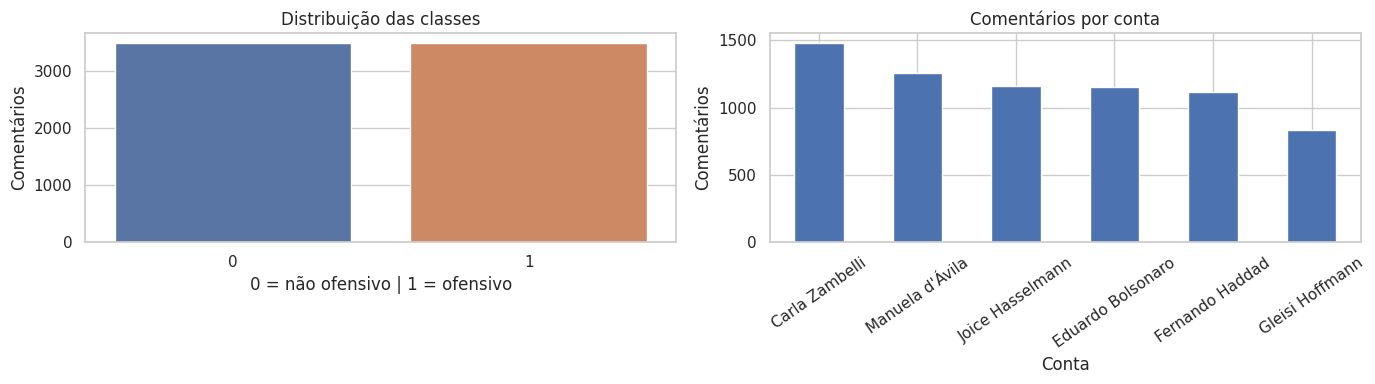

,comentarios
account_post,
Carla Zambelli,1481
Manuela d'Ávila,1258
Joice Hasselmann,1158
Eduardo Bolsonaro,1151
Fernando Haddad,1118
Gleisi Hoffmann,834


In [ ]:
print("Contas únicas:",df.account_post.nunique(),"| Posts únicos:",df.links_post.nunique())
fig,axes=plt.subplots(1,2,figsize=(14,4))
sns.countplot(data=df,x=LABEL_COL,hue=LABEL_COL,legend=False,ax=axes[0])
axes[0].set(title="Distribuição das classes",xlabel="0 = não ofensivo | 1 = ofensivo",ylabel="Comentários")
df.account_post.value_counts().plot(kind="bar",ax=axes[1],color="#4C72B0")
axes[1].set(title="Comentários por conta",xlabel="Conta",ylabel="Comentários"); axes[1].tick_params(axis="x",rotation=35)
plt.tight_layout(); plt.show(); display(df.account_post.value_counts().rename("comentarios").to_frame())

## 5. Divisão treino/validação/teste
Divisão estratificada 70%/15%/15%, persistida por ID e igual para todos os modelos.

In [ ]:
splits=create_or_load_splits(dataset,OUTPUT_DIR,seed=SEED); train,valid,test=splits["train"],splits["valid"],splits["test"]
display(pd.DataFrame({n:{"linhas":len(x),"classe_0":int((x[LABEL_COL]==0).sum()),"classe_1":int((x[LABEL_COL]==1).sum())} for n,x in splits.items()}).T)

,linhas,classe_0,classe_1
train,4900,2450,2450
valid,1050,525,525
test,1050,525,525


## 6. Instruções manuais e automáticas
As instruções manuais são comparadas em inglês e português. Falhas automáticas interrompem a execução.

In [ ]:
# 3. INSTRUÇÕES AUTOMÁTICAS
# =============================================================================


def atomic_json_write(path: Path, value: object) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(
        json.dumps(value, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    temporary.replace(path)


def extract_json_array(raw: str) -> list[str]:
    cleaned = raw.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`").strip()
        if cleaned.lower().startswith("json"):
            cleaned = cleaned[4:].strip()
    parsed = json.loads(cleaned)
    if not isinstance(parsed, list) or not all(isinstance(item, str) for item in parsed):
        raise ValueError("A LLM não retornou um array JSON de strings.")
    result = [item.strip() for item in parsed]
    if any(not item for item in result):
        raise ValueError("A LLM retornou uma instrução vazia.")
    return result


def instruction_prompt(texts: list[str], language: str) -> str:
    numbered = "\n".join(f"{index + 1}. {text}" for index, text in enumerate(texts))
    if language == "pt":
        return (
            "Você receberá comentários em português brasileiro. Para cada comentário, "
            "gere uma instrução curta (máximo de 25 palavras), em português, que diga a "
            "um modelo de embeddings quais indícios observar para detectar discurso de "
            "ódio. Não decida o rótulo. Retorne apenas um array JSON de strings, na "
            "mesma ordem e com o mesmo tamanho da entrada.\n\n" + numbered
        )
    if language == "en":
        return (
            "You will receive Brazilian Portuguese comments. For each comment, generate "
            "one short instruction (at most 25 words), in English, telling an embedding "
            "model which cues to inspect for hate-speech detection. Do not decide the "
            "label. Return only a JSON string array in the same order and with the same "
            "length as the input.\n\n" + numbered
        )
    raise ValueError(f"Idioma de instrução inválido: {language}")


def generate_automatic_instructions(
    frames: Iterable[pd.DataFrame],
    language: str,
    cache_path: str | Path,
    model: str = "llama-3.1-8b-instant",
    batch_size: int = 10,
    max_retries: int = 4,
    rpm_limit: int = 25,
) -> dict[int, str]:
    """Gera instruções por lote sem substituir falhas por baseline."""

    api_key = os.environ.get("GROQ_API_KEY")
    if not api_key:
        raise RuntimeError(
            "GROQ_API_KEY não definida. A chave deve ficar no ambiente, nunca no código."
        )
    try:
        import requests
    except ImportError as exc:
        raise RuntimeError(
            "requests não instalado. Execute: pip install -r requirements.txt"
        ) from exc

    cache_path = Path(cache_path)
    if cache_path.exists():
        raw_cache = json.loads(cache_path.read_text(encoding="utf-8"))
        cache = {int(key): str(value).strip() for key, value in raw_cache.items()}
    else:
        cache = {}

    records = pd.concat(list(frames), ignore_index=True)[[ID_COL, TEXT_COL]]
    pending = [
        (int(row[ID_COL]), str(row[TEXT_COL]))
        for _, row in records.iterrows()
        if not cache.get(int(row[ID_COL]), "").strip()
    ]
    batches = [pending[i : i + batch_size] for i in range(0, len(pending), batch_size)]
    minimum_interval = 60.0 / max(1, rpm_limit)
    last_call = 0.0

    print(
        f"[instruções {language}] {len(pending)} pendentes em {len(batches)} lotes"
    )
    for batch_number, batch in enumerate(batches, start=1):
        ids = [item[0] for item in batch]
        texts = [item[1] for item in batch]
        payload = {
            "model": model,
            "messages": [
                {"role": "user", "content": instruction_prompt(texts, language)}
            ],
            "temperature": 0.0,
            "max_tokens": 60 * len(texts),
        }
        error: Exception | None = None
        for attempt in range(max_retries):
            wait = minimum_interval - (time.monotonic() - last_call)
            if wait > 0:
                time.sleep(wait)
            last_call = time.monotonic()
            try:
                response = requests.post(
                    "https://api.groq.com/openai/v1/chat/completions",
                    headers={"Authorization": f"Bearer {api_key}"},
                    json=payload,
                    timeout=90,
                )
                if response.status_code == 429:
                    time.sleep(5 * (attempt + 1))
                    continue
                response.raise_for_status()
                result = extract_json_array(
                    response.json()["choices"][0]["message"]["content"]
                )
                if len(result) != len(batch):
                    raise ValueError(
                        f"Esperava {len(batch)} instruções; recebi {len(result)}."
                    )
                cache.update(dict(zip(ids, result)))
                atomic_json_write(cache_path, {str(k): v for k, v in cache.items()})
                error = None
                break
            except (
                requests.RequestException,
                json.JSONDecodeError,
                KeyError,
                TypeError,
                ValueError,
            ) as exc:
                error = exc
                time.sleep(2 * (attempt + 1))
        if error is not None:
            raise RuntimeError(
                f"Falha no lote {batch_number}/{len(batches)}; o cache parcial foi "
                f"preservado. Motivo: {error}"
            ) from error

    missing = [
        int(identifier)
        for identifier in records[ID_COL]
        if not cache.get(int(identifier), "").strip()
    ]
    if missing:
        raise RuntimeError(
            f"Cache incompleto: faltam {len(missing)} instruções. "
            "O experimento não continuará para evitar mistura com o baseline."
        )
    return cache



## 7. Embeddings e cache
O cache registra modelo, revisão, condição, split, hash do dataset e hash da entrada. Um encoder é carregado por vez.

In [ ]:
# 4. FORMATAÇÃO E CACHE DE EMBEDDINGS
# =============================================================================


def input_digest(values: Sequence[str]) -> str:
    digest = hashlib.sha256()
    for value in values:
        encoded = value.encode("utf-8")
        digest.update(len(encoded).to_bytes(8, "big"))
        digest.update(encoded)
    return digest.hexdigest()


def slug(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_.-]+", "_", value).strip("_")


def format_inputs(
    config: ModelConfig,
    condition: str,
    texts: Sequence[str],
    automatic_instructions: Sequence[str] | None = None,
) -> list[str]:
    """Aplica exatamente o formato esperado por cada família de modelo."""

    if not config.supports_condition(condition):
        raise ValueError(
            f"{config.name} não foi treinado para a condição '{condition}'. "
            "Modelos não instrucionais só podem ser usados em 'sem_instrucao'."
        )

    if condition == SEM_INSTRUCAO:
        if config.input_style in {"e5_query", "e5_instruct"}:
            return [f"query: {text}" for text in texts]
        return list(texts)

    if config.input_style != "e5_instruct":
        raise ValueError(f"Estilo instrucional não implementado: {config.input_style}")

    if condition == MANUAL_EN:
        instructions = [MANUAL_INSTRUCTIONS["en"]] * len(texts)
    elif condition == MANUAL_PT:
        instructions = [MANUAL_INSTRUCTIONS["pt"]] * len(texts)
    elif condition in {AUTOMATICA_EN, AUTOMATICA_PT}:
        if automatic_instructions is None:
            raise ValueError(f"Instruções ausentes para a condição '{condition}'.")
        if len(automatic_instructions) != len(texts):
            raise ValueError("Quantidade de instruções diferente da quantidade de textos.")
        instructions = [str(item).strip() for item in automatic_instructions]
        if any(not item for item in instructions):
            raise ValueError(
                "Há instruções automáticas vazias. O baseline não será usado como fallback."
            )
    else:
        raise ValueError(f"Condição desconhecida: {condition}")

    return [
        f"Instruct: {instruction}\nQuery: {text}"
        for instruction, text in zip(instructions, texts)
    ]


def load_sentence_transformer(config: ModelConfig, device: str | None = None):
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as exc:
        raise RuntimeError(
            "sentence-transformers não instalado. Use Python 3.10-3.12 e execute: "
            "pip install -r requirements.txt"
        ) from exc

    kwargs: dict[str, Any] = {"trust_remote_code": False}
    if device and device != "auto":
        kwargs["device"] = device
    return SentenceTransformer(config.hf_id, **kwargs)


def resolved_model_revision(model: object) -> str:
    try:
        transformer = model[0]
        revision = transformer.auto_model.config._commit_hash
        return str(revision or "unknown")
    except (AttributeError, IndexError, TypeError):
        return "unknown"


class EmbeddingCache:
    """Cache que recusa embeddings de outro modelo/configuração/texto."""

    def __init__(self, root: str | Path):
        self.root = Path(root)

    def paths(
        self,
        dataset_sha256: str,
        config: ModelConfig,
        condition: str,
        split: str,
    ) -> tuple[Path, Path]:
        directory = (
            self.root
            / "v2"
            / dataset_sha256[:16]
            / slug(config.hf_id)
            / condition
        )
        return directory / f"{split}.npy", directory / f"{split}.json"

    def load(
        self,
        dataset_sha256: str,
        config: ModelConfig,
        condition: str,
        split: str,
        formatted_inputs: Sequence[str],
    ) -> np.ndarray | None:
        array_path, metadata_path = self.paths(
            dataset_sha256, config, condition, split
        )
        if not array_path.exists() or not metadata_path.exists():
            return None
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
            expected = {
                "model_id": config.hf_id,
                "condition": condition,
                "split": split,
                "dataset_sha256": dataset_sha256,
                "input_sha256": input_digest(formatted_inputs),
                "rows": len(formatted_inputs),
            }
            if any(metadata.get(key) != value for key, value in expected.items()):
                return None
            array = np.load(array_path, allow_pickle=False)
            if (
                array.ndim != 2
                or array.shape[0] != len(formatted_inputs)
                or not np.isfinite(array).all()
            ):
                return None
            return array
        except (OSError, ValueError, json.JSONDecodeError):
            return None

    def save(
        self,
        array: np.ndarray,
        dataset_sha256: str,
        config: ModelConfig,
        condition: str,
        split: str,
        formatted_inputs: Sequence[str],
        model_revision: str,
    ) -> None:
        array_path, metadata_path = self.paths(
            dataset_sha256, config, condition, split
        )
        array_path.parent.mkdir(parents=True, exist_ok=True)
        array_tmp = array_path.with_suffix(".npy.tmp")
        metadata_tmp = metadata_path.with_suffix(".json.tmp")
        with array_tmp.open("wb") as stream:
            np.save(stream, np.asarray(array, dtype=np.float32), allow_pickle=False)
        metadata = {
            "model_id": config.hf_id,
            "model_revision": model_revision,
            "condition": condition,
            "split": split,
            "dataset_sha256": dataset_sha256,
            "input_sha256": input_digest(formatted_inputs),
            "rows": len(formatted_inputs),
            "dimensions": int(array.shape[1]),
            "normalized": True,
        }
        metadata_tmp.write_text(
            json.dumps(metadata, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        os.replace(array_tmp, array_path)
        os.replace(metadata_tmp, metadata_path)


def get_or_encode(
    model: object,
    config: ModelConfig,
    cache: EmbeddingCache,
    dataset_sha256: str,
    condition: str,
    split: str,
    texts: Sequence[str],
    automatic_instructions: Sequence[str] | None,
    batch_size: int,
    force: bool = False,
) -> np.ndarray:
    formatted = format_inputs(
        config,
        condition,
        texts,
        automatic_instructions=automatic_instructions,
    )
    if not force:
        cached = cache.load(dataset_sha256, config, condition, split, formatted)
        if cached is not None:
            print(f"[cache] {config.name} | {condition} | {split}")
            return cached

    embeddings = model.encode(
        formatted,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    )
    embeddings = np.asarray(embeddings, dtype=np.float32)
    if embeddings.ndim != 2 or embeddings.shape[0] != len(texts):
        raise RuntimeError(
            f"Formato inesperado de embeddings: {embeddings.shape}; "
            f"esperava {len(texts)} linhas."
        )
    if not np.isfinite(embeddings).all():
        raise RuntimeError("O modelo produziu valores NaN ou infinitos.")

    cache.save(
        embeddings,
        dataset_sha256,
        config,
        condition,
        split,
        formatted,
        model_revision=resolved_model_revision(model),
    )
    return embeddings



## 8. Classificação e métricas
Regressão logística como sonda linear; `C` selecionado na validação; teste usado uma vez; F1-macro com bootstrap de 95%.

In [ ]:
@dataclass(slots=True)
class EvaluationResult:
    metrics: dict[str, float]
    predictions: np.ndarray
    best_c: float


def classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    try:
        from sklearn.metrics import (
            accuracy_score,
            balanced_accuracy_score,
            f1_score,
            matthews_corrcoef,
            precision_score,
            recall_score,
        )
    except ImportError as exc:
        raise RuntimeError(
            "scikit-learn não instalado. Execute: pip install -r requirements.txt"
        ) from exc

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_weighted": float(
            precision_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "recall_weighted": float(
            recall_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "f1_weighted": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "f1_macro": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
    }


def evaluate_linear_probe(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_valid: np.ndarray,
    y_valid: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    seed: int = SEED,
    c_values: tuple[float, ...] = (0.1, 1.0, 10.0),
    bootstrap_samples: int = 500,
) -> EvaluationResult:
    """Seleciona C na validação e avalia o teste uma única vez."""

    try:
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import f1_score
    except ImportError as exc:
        raise RuntimeError(
            "scikit-learn não instalado. Execute: pip install -r requirements.txt"
        ) from exc

    best_c = c_values[0]
    best_score = -1.0
    for c_value in c_values:
        classifier = LogisticRegression(
            C=c_value,
            max_iter=2000,
            random_state=seed,
            solver="lbfgs",
        )
        classifier.fit(x_train, y_train)
        score = f1_score(
            y_valid,
            classifier.predict(x_valid),
            average="macro",
            zero_division=0,
        )
        if score > best_score:
            best_score = float(score)
            best_c = c_value

    classifier = LogisticRegression(
        C=best_c,
        max_iter=2000,
        random_state=seed,
        solver="lbfgs",
    )
    classifier.fit(
        np.concatenate([x_train, x_valid], axis=0),
        np.concatenate([y_train, y_valid], axis=0),
    )
    predictions = classifier.predict(x_test)
    metrics = classification_metrics(y_test, predictions)

    if bootstrap_samples > 0:
        from sklearn.metrics import f1_score

        rng = np.random.default_rng(seed)
        scores = np.empty(bootstrap_samples, dtype=np.float64)
        for index in range(bootstrap_samples):
            sample = rng.integers(0, len(y_test), size=len(y_test))
            scores[index] = f1_score(
                y_test[sample],
                predictions[sample],
                average="macro",
                zero_division=0,
            )
        metrics["f1_macro_ci95_low"] = float(np.quantile(scores, 0.025))
        metrics["f1_macro_ci95_high"] = float(np.quantile(scores, 0.975))

    return EvaluationResult(
        metrics=metrics,
        predictions=np.asarray(predictions),
        best_c=float(best_c),
    )



## 9. Pipeline completo

In [ ]:
# 6. PIPELINE COMPLETO
# =============================================================================


def release_accelerator_cache() -> None:
    gc.collect()
    try:
        import torch

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except ImportError:
        pass


def validate_model_names(names: list[str] | tuple[str, ...]) -> list[str]:
    unknown = sorted(set(names) - MODEL_REGISTRY.keys())
    if unknown:
        raise ValueError(
            f"Modelo(s) desconhecido(s): {', '.join(unknown)}. "
            f"Opções: {', '.join(MODEL_REGISTRY)}"
        )
    return list(dict.fromkeys(names))


def validate_conditions(conditions: list[str] | tuple[str, ...]) -> list[str]:
    unknown = sorted(set(conditions) - set(TODAS_CONDICOES))
    if unknown:
        raise ValueError(
            f"Condição(ões) desconhecida(s): {', '.join(unknown)}. "
            f"Opções: {', '.join(TODAS_CONDICOES)}"
        )
    return list(dict.fromkeys(conditions))


def run_experiment(
    data_path: str | Path,
    cache_dir: str | Path,
    output_dir: str | Path,
    model_names: list[str],
    conditions: list[str],
    seed: int = SEED,
    batch_size: int = 32,
    device: str = "auto",
    force_embeddings: bool = False,
    groq_model: str = "llama-3.1-8b-instant",
    bootstrap_samples: int = 500,
) -> pd.DataFrame:
    """Executa embeddings, classificador, métricas e arquivos de saída."""

    started = time.time()
    output_dir = Path(output_dir)
    cache_dir = Path(cache_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    cache_dir.mkdir(parents=True, exist_ok=True)

    dataset = load_dataset(data_path)
    splits = create_or_load_splits(dataset, output_dir=output_dir, seed=seed)
    print(
        "Divisão:",
        " | ".join(f"{name}={len(frame)}" for name, frame in splits.items()),
    )

    instruction_maps: dict[str, dict[int, str]] = {}
    for language, condition in (("en", AUTOMATICA_EN), ("pt", AUTOMATICA_PT)):
        condition_is_applicable = condition in conditions and any(
            MODEL_REGISTRY[name].supports_condition(condition)
            for name in model_names
        )
        if condition_is_applicable:
            instruction_maps[language] = generate_automatic_instructions(
                splits.values(),
                language=language,
                cache_path=(
                    cache_dir
                    / "v2"
                    / dataset.sha256[:16]
                    / f"automatic_instructions_{language}.json"
                ),
                model=groq_model,
            )

    cache = EmbeddingCache(cache_dir)
    result_rows: list[dict[str, object]] = []
    prediction_frames: list[pd.DataFrame] = []

    for model_name in model_names:
        config = MODEL_REGISTRY[model_name]
        applicable = [
            condition for condition in conditions if config.supports_condition(condition)
        ]
        skipped = [condition for condition in conditions if condition not in applicable]
        for condition in skipped:
            print(f"[ignorado] {model_name} | {condition}: modelo não instrucional")
        if not applicable:
            continue

        print(f"\nCarregando {model_name}: {config.hf_id}")
        model = load_sentence_transformer(config, device=device)
        try:
            for condition in applicable:
                arrays: dict[str, np.ndarray] = {}
                for split_name, frame in splits.items():
                    language = (
                        "en"
                        if condition == AUTOMATICA_EN
                        else "pt"
                        if condition == AUTOMATICA_PT
                        else None
                    )
                    automatic = None
                    if language:
                        instruction_map = instruction_maps[language]
                        automatic = [
                            instruction_map[int(identifier)]
                            for identifier in frame[ID_COL]
                        ]
                    arrays[split_name] = get_or_encode(
                        model=model,
                        config=config,
                        cache=cache,
                        dataset_sha256=dataset.sha256,
                        condition=condition,
                        split=split_name,
                        texts=frame[TEXT_COL].astype(str).tolist(),
                        automatic_instructions=automatic,
                        batch_size=batch_size,
                        force=force_embeddings,
                    )

                evaluation = evaluate_linear_probe(
                    arrays["train"],
                    splits["train"][LABEL_COL].to_numpy(),
                    arrays["valid"],
                    splits["valid"][LABEL_COL].to_numpy(),
                    arrays["test"],
                    splits["test"][LABEL_COL].to_numpy(),
                    seed=seed,
                    bootstrap_samples=bootstrap_samples,
                )
                row: dict[str, object] = {
                    "modelo": model_name,
                    "model_id": config.hf_id,
                    "condicao": condition,
                    "dimensoes": int(arrays["train"].shape[1]),
                    "melhor_C": evaluation.best_c,
                    **evaluation.metrics,
                }
                result_rows.append(row)
                prediction_frames.append(
                    pd.DataFrame(
                        {
                            ID_COL: splits["test"][ID_COL].to_numpy(),
                            LABEL_COL: splits["test"][LABEL_COL].to_numpy(),
                            "predicao": evaluation.predictions,
                            "modelo": model_name,
                            "condicao": condition,
                        }
                    )
                )
                print(
                    f"[resultado] {model_name} | {condition}: "
                    f"F1-macro={evaluation.metrics['f1_macro']:.4f}"
                )
        finally:
            del model
            release_accelerator_cache()

    if not result_rows:
        raise RuntimeError("Nenhuma combinação modelo/condição pôde ser executada.")

    results = pd.DataFrame(result_rows).sort_values(
        ["f1_macro", "modelo", "condicao"],
        ascending=[False, True, True],
    )
    results.to_csv(output_dir / "resultados_comparativos.csv", index=False)
    pd.concat(prediction_frames, ignore_index=True).to_csv(
        output_dir / "predicoes_teste.csv",
        index=False,
    )
    (output_dir / "execucao.json").write_text(
        json.dumps(
            {
                "dataset": str(dataset.path),
                "dataset_sha256": dataset.sha256,
                "dataset_audit": dataset.audit,
                "models": model_names,
                "conditions": conditions,
                "seed": seed,
                "batch_size": batch_size,
                "device": device,
                "python": sys.version,
                "platform": platform.platform(),
                "elapsed_seconds": round(time.time() - started, 3),
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )
    return results



## 10. Execução principal
A primeira execução baixa os modelos e pode demorar. Somente o E5-instruct executará condições manuais.

In [ ]:
MODELOS_ESCOLHIDOS=["e5_base","e5_large_instruct","minilm_multilingual","bertimbau_sts"]
CONDICOES_ESCOLHIDAS=["sem_instrucao","manual_en","manual_pt"]
BATCH_SIZE=32; BOOTSTRAP_SAMPLES=500
resultados=run_experiment(data_path=DATA_PATH,cache_dir=CACHE_DIR,output_dir=OUTPUT_DIR,model_names=validate_model_names(MODELOS_ESCOLHIDOS),conditions=validate_conditions(CONDICOES_ESCOLHIDAS),seed=SEED,batch_size=BATCH_SIZE,device="auto",bootstrap_samples=BOOTSTRAP_SAMPLES)
display(resultados)

Divisão: train=4900 | valid=1050 | test=1050
[ignorado] e5_base | manual_en: modelo não instrucional
[ignorado] e5_base | manual_pt: modelo não instrucional

Carregando e5_base: intfloat/multilingual-e5-base


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/154 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

[resultado] bertimbau_sts | sem_instrucao: F1-macro=0.8828


,modelo,model_id,condicao,dimensoes,melhor_C,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,mcc,f1_macro_ci95_low,f1_macro_ci95_high
1,e5_large_instruct,intfloat/multilingual-e5-large-instruct,sem_instrucao,1024,10.0,0.904762,0.904762,0.904768,0.904762,0.904762,0.904762,0.809530,0.885706,0.922314
2,e5_large_instruct,intfloat/multilingual-e5-large-instruct,manual_en,1024,10.0,0.900952,0.900952,0.901162,0.900952,0.900939,0.900939,0.802114,0.881311,0.918089
3,e5_large_instruct,intfloat/multilingual-e5-large-instruct,manual_pt,1024,10.0,0.899048,0.899048,0.899750,0.899048,0.899003,0.899003,0.798797,0.879428,0.916190
5,bertimbau_sts,rufimelo/bert-large-portuguese-cased-sts,sem_instrucao,1024,10.0,0.882857,0.882857,0.883092,0.882857,0.882839,0.882839,0.765949,0.862702,0.901632
0,e5_base,intfloat/multilingual-e5-base,sem_instrucao,768,10.0,0.881905,0.881905,0.881993,0.881905,0.881898,0.881898,0.763898,0.861240,0.900380
4,minilm_multilingual,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,sem_instrucao,384,10.0,0.848571,0.848571,0.848633,0.848571,0.848565,0.848565,0.697205,0.825566,0.870304


## 11. Ranking e gráfico comparativo

,modelo,condicao,f1_macro,f1_macro_ci95_low,f1_macro_ci95_high,accuracy,mcc,dimensoes
0,e5_large_instruct,sem_instrucao,0.904762,0.885706,0.922314,0.904762,0.809530,1024
1,e5_large_instruct,manual_en,0.900939,0.881311,0.918089,0.900952,0.802114,1024
2,e5_large_instruct,manual_pt,0.899003,0.879428,0.916190,0.899048,0.798797,1024
3,bertimbau_sts,sem_instrucao,0.882839,0.862702,0.901632,0.882857,0.765949,1024
4,e5_base,sem_instrucao,0.881898,0.861240,0.900380,0.881905,0.763898,768
5,minilm_multilingual,sem_instrucao,0.848565,0.825566,0.870304,0.848571,0.697205,384


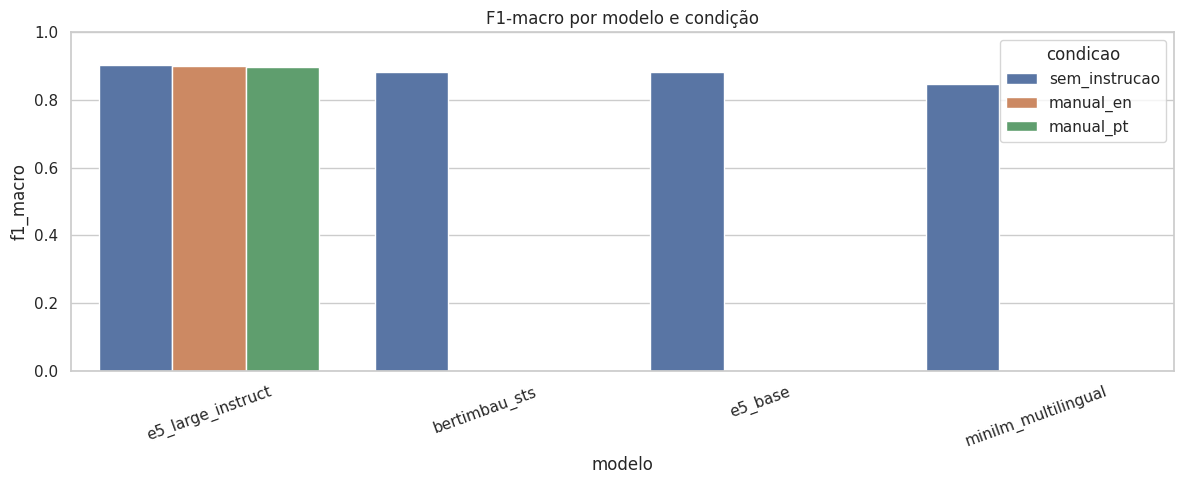

In [ ]:
r=resultados.sort_values("f1_macro",ascending=False).reset_index(drop=True)
display(r[["modelo","condicao","f1_macro","f1_macro_ci95_low","f1_macro_ci95_high","accuracy","mcc","dimensoes"]])
plt.figure(figsize=(12,5)); sns.barplot(data=r,x="modelo",y="f1_macro",hue="condicao"); plt.ylim(0,1)
plt.title("F1-macro por modelo e condição"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### Matrizes de confusão e relatórios

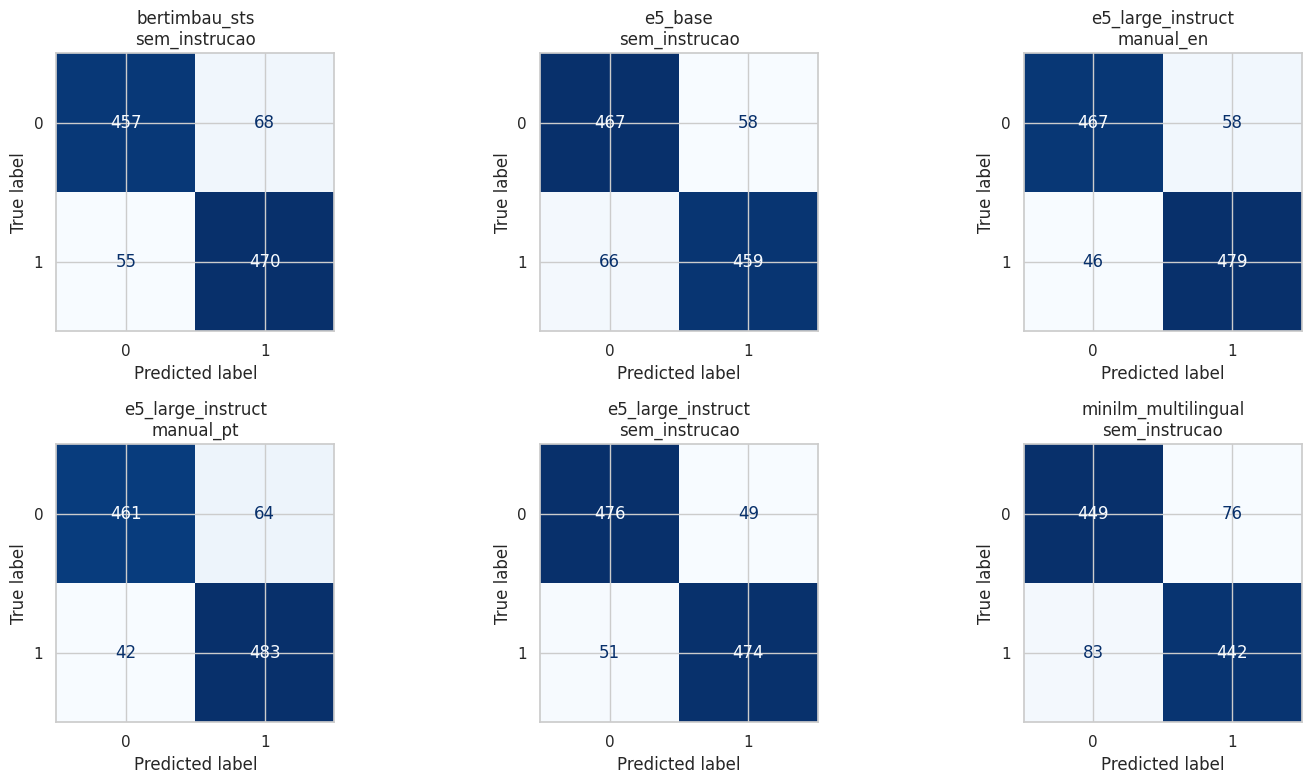


=== bertimbau_sts | sem_instrucao ===
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       525
           1       0.87      0.90      0.88       525

    accuracy                           0.88      1050
   macro avg       0.88      0.88      0.88      1050
weighted avg       0.88      0.88      0.88      1050


=== e5_base | sem_instrucao ===
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       525
           1       0.89      0.87      0.88       525

    accuracy                           0.88      1050
   macro avg       0.88      0.88      0.88      1050
weighted avg       0.88      0.88      0.88      1050


=== e5_large_instruct | manual_en ===
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       525
           1       0.89      0.91      0.90       525

    accuracy                           0.90      1050
   macro avg     

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report,confusion_matrix
predicoes=pd.read_csv(OUTPUT_DIR/"predicoes_teste.csv"); combos=list(predicoes.groupby(["modelo","condicao"]).groups)
cols=3; rows=int(np.ceil(len(combos)/cols)); fig,axes=plt.subplots(rows,cols,figsize=(5*cols,4*rows),squeeze=False)
for ax,(modelo,condicao) in zip(axes.flat,combos):
 s=predicoes.query("modelo == @modelo and condicao == @condicao"); cm=confusion_matrix(s[LABEL_COL],s.predicao,labels=[0,1])
 ConfusionMatrixDisplay(cm,display_labels=[0,1]).plot(ax=ax,cmap="Blues",colorbar=False); ax.set_title(f"{modelo}\n{condicao}")
for ax in axes.flat[len(combos):]: ax.axis("off")
plt.tight_layout(); plt.show()
for modelo,condicao in combos:
 s=predicoes.query("modelo == @modelo and condicao == @condicao"); print(f"\n=== {modelo} | {condicao} ===")
 print(classification_report(s[LABEL_COL],s.predicao,zero_division=0))

### Erros e comparação

In [ ]:
detalhes=predicoes.merge(test[[ID_COL,TEXT_COL,LABEL_COL]],on=[ID_COL,LABEL_COL],how="left"); detalhes["erro"]=detalhes[LABEL_COL]!=detalhes.predicao
erros=detalhes[detalhes.erro].copy(); erros.to_csv(OUTPUT_DIR/"analise_erros_detalhada.csv",index=False)
resumo_erros=detalhes.groupby(["modelo","condicao"]).erro.agg(total_erros="sum",taxa_erro="mean").reset_index().sort_values("taxa_erro"); display(resumo_erros)
e5=detalhes.query("modelo == 'e5_large_instruct'")
if {"manual_en","manual_pt"}.issubset(set(e5.condicao)):
 comp=e5.pivot_table(index=[ID_COL,TEXT_COL,LABEL_COL],columns="condicao",values="predicao",aggfunc="first").reset_index()
 comp["predicoes_diferentes"]=comp.manual_en!=comp.manual_pt; comp["en_correta"]=comp.manual_en==comp[LABEL_COL]; comp["pt_correta"]=comp.manual_pt==comp[LABEL_COL]
 dif=comp[comp.predicoes_diferentes].copy(); dif.to_csv(OUTPUT_DIR/"comparacao_instrucao_ingles_portugues.csv",index=False)
 print("Decisões diferentes EN vs PT:",len(dif)); display(dif.head(30))

,modelo,condicao,total_erros,taxa_erro
4,e5_large_instruct,sem_instrucao,100,0.095238
2,e5_large_instruct,manual_en,104,0.099048
3,e5_large_instruct,manual_pt,106,0.100952
0,bertimbau_sts,sem_instrucao,123,0.117143
1,e5_base,sem_instrucao,124,0.118095
5,minilm_multilingual,sem_instrucao,159,0.151429


Decisões diferentes EN vs PT: 32


condicao,id,comentario,label_final,manual_en,manual_pt,sem_instrucao,predicoes_diferentes,en_correta,pt_correta
42,284,"Os inteligente na pista kkkk o que mais que a galera sabe me contam eu não sabia dessa será que sou burra, a não eu ...",1,1,0,1,True,True,False
64,420,Fora bozzolino! Christina vamos a volver✌✌✌,1,0,1,0,True,False,True
97,632,Até quando o STF vai trabalhar contra o país?,1,0,1,1,True,False,True
102,649,"Para que tanta inveja Muié, o povo tem que manifestar mesmo para provar que Bolsonaro é mais amado que o *L* o perso...",1,0,1,0,True,False,True
110,680,A grande destruição ambiental no Brasil ocorreu principalmente durante os anos que a europa nos colonizava e hj euro...,1,0,1,0,True,False,True
135,925,Não existe gabinete do ódio do lado.debbolsonaro isso é coisa de lula,1,1,0,1,True,True,False
158,1090,Ainda aplaudem uma carniça dessas...,1,0,1,1,True,False,True
162,1103,"Nojo, ta passando dos limites",1,0,1,1,True,False,True
223,1539,Um homem de Deus que nem o diabo quer .,1,1,0,1,True,True,False
270,1839,"No Brasil ñ pensou, e sim na sua pessoa. Patriota de bosta",1,0,1,0,True,False,True


## 12. Instruções automáticas por LLM (opcional)
Cadastre `GROQ_API_KEY` em **Secrets** e altere a variável para `True`. Nunca escreva a chave no notebook.

In [ ]:
EXECUTAR_INSTRUCOES_AUTOMATICAS=False
if EXECUTAR_INSTRUCOES_AUTOMATICAS:
 from google.colab import userdata
 os.environ["GROQ_API_KEY"]=userdata.get("GROQ_API_KEY")
 if not os.environ.get("GROQ_API_KEY"): raise RuntimeError("Cadastre GROQ_API_KEY em Secrets")
 resultados_auto=run_experiment(data_path=DATA_PATH,cache_dir=CACHE_DIR,output_dir=BASE_DIR/"resultados_hatebr_automaticos",model_names=["e5_large_instruct"],conditions=["sem_instrucao","manual_en","manual_pt","automatica_en","automatica_pt"],seed=SEED,batch_size=BATCH_SIZE,device="auto",bootstrap_samples=BOOTSTRAP_SAMPLES)
 display(resultados_auto)
else: print("Etapa automática desativada. Altere para True se desejar executá-la.")

Etapa automática desativada. Altere para True se desejar executá-la.


## 13. Exportação

In [ ]:
BAIXAR_RESULTADOS=False
if BAIXAR_RESULTADOS:
 arquivo=shutil.make_archive(str(BASE_DIR/"resultados_hatebr"),"zip",root_dir=OUTPUT_DIR); print("Criado:",arquivo)
 try:
  from google.colab import files
  files.download(arquivo)
 except ImportError: pass
else: print("Resultados em:",OUTPUT_DIR)

Resultados em: /content/resultados_hatebr


## Referências
- Vargas et al. (2022), *HateBR: A Large Expert Annotated Corpus of Brazilian Instagram Comments for Offensive Language and Hate Speech Detection*.
- Wang et al. (2024), *Multilingual E5 Text Embeddings: A Technical Report*.
- Su et al. (2022), *One Embedder, Any Task: Instruction-Finetuned Text Embeddings*.
- Fonte oficial: https://github.com/franciellevargas/HateBR

Execute este notebook para resultados novos. As métricas antigas não são evidência final devido à falta de proveniência e às instruções ausentes.